In [1]:
import numpy as np

import gymnasium as gym
from gymnasium.wrappers import RecordEpisodeStatistics

from collections import deque

In [2]:
def print_nn_state(network):
    for key in network.state_dict.keys():
        if not key.startswith('_'):
            layer = network.state_dict[key]
            print(f'{key} input: ', layer._last_input)
            print(f'{key} weights: \n', layer.state_dict['weights'])
            print(f'{key} bias: ', layer.state_dict['bias'])
            print(f'{key} output: ', layer._last_output)
            print('=' * 60)


def tanh_activation(layer, x):
    """ Applies TanH activation """
    layer._a_output = np.tanh(x)
    layer._grad_fn = 'tanh'
    return layer._a_output

def tanh_derivative(x):
    return 1 - np.tanh(x)

def relu_activation(layer, x):
    """ Applies ReLU activation function and tracks it """
    layer._a_output = np.maximum(0, x)
    layer._grad_fn = 'relu'
    return layer._a_output

def relu_derivative(x):
    return (x > 0).astype(float)

def softplus_activation(layer, x):
    """ Computes the Softplus activation function: ln(1 + e^x) """
    layer._grad_fn = 'softplus'
    return np.log1p(np.exp(x))  # log1p is numerically stable for small x
    
def softplus_derivative(x):
    """ Computes the derivative of Softplus, which is the Sigmoid function """
    return 1 / (1 + np.exp(-x))

def log_probability(x, mu, sigma):
    """ Computes the log probability of a sample x under a normal distribution with mean mu and std sigma. """
    return -0.5 * (np.log(2 * np.pi) + 2 * np.log(sigma) + ((x - mu) ** 2) / (sigma ** 2))

def gaussian_entropy(sigma):
    """ Computes the entropy of a Gaussian distribution with standard deviation sigma. """
    return 0.5 * (np.log(2 * np.pi * np.e * sigma**2))

def compute_gae(next_value: list[int], rewards, dones: list[tuple[bool, bool]], values: list[int], gamma: float, lam: float) -> tuple[float, float]:
    """
    Compute Generalized Advantage Estimation (GAE).
    """
    values = values + [next_value]
    gae = 0  # Initial value of the advantage
    returns = deque([])
    advantages = deque([])

    for step in reversed(range(len(rewards))):
        delta = rewards[step] + gamma * values[step + 1] * (1 - dones[step]) - values[step]
        gae = delta + gamma * lam * (1 - dones[step]) * gae
        returns.appendleft(gae + values[step])
        advantages.appendleft(gae)

    # Normalize advantages
    advantages = np.array(advantages)
    advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

    return np.array(returns), advantages

def mse(predicted, true):
    return np.mean((predicted - true) ** 2) / true.size 


class Memory:
    def __init__(self):
        self.states = []
        self.rewards = []
        self.dones = []
        self.log_probs = []
        self.actions = []
        self.critic_values = []

    def clear(self):
        for key in self.__dict__.keys():
            self.__dict__[key].clear()

class Bias:
    def __init__(self, h_size: int) -> None:
        self._h_size = h_size
        self._value = None

    @property
    def value(self):
        if self._value is None:
            self._value = self._generate_value()

        return self._value

    def _generate_value(self):
        return np.random.uniform(-0.5, 0.5, size=(1, self._h_size))

    def __call__(self):
        return self.value

    def __repr__(self):
        return str(self.__dict__)


class Weight:
    def __init__(self, v_size: int, h_size: int):
        self._v_size = v_size
        self._h_size = h_size
        self._value = None

    @property
    def value(self):
        if self._value is None:
            self._value = self._generate_value()

        return self._value

    def _generate_value(self):
        return np.random.uniform(-0.5, 0.5, size=(self._v_size, self._h_size))

    def __call__(self):
        return self.value

    def __repr__(self):
        return str(self.__dict__)


class LinearLayer:
    def __init__(self, in_features: int, out_features: int, require_grad=True):
        self.in_features = in_features
        self.out_features = out_features
        self.bias = Bias(out_features)()
        self.weights = Weight(in_features, out_features)()
        self._input = None  # store input values either activated or not
        self._z_output = None  # Store output before activation
        self._a_output = None  # Store output after activation
        self._grad_fn: str = None # tracks activated function type

    @property
    def state_dict(self):
        return dict(
            weights=self.weights,
            bias=self.bias,
        )

    def forward(self, x):
        """ Linear transformation W.X + B """
        self._input = x # save the input
        self._z_output = np.dot(self._input, self.weights) + self.bias # save values before activation
        return self._z_output

    def backward(self, dldy, lr):
        """ Backpropagate gradients and update weights & bias """
        # ensure numpy array
        if isinstance(self._input, list):
            self._input = np.array(self._input)        
        
        # Ensure dldy has the correct shape
        if np.isscalar(dldy):
            dldy = np.full_like(self._z_output, dldy)  # Expand scalar loss
    
        elif dldy.shape != self._z_output.shape:
            dldy = dldy.reshape(self._z_output.shape)  # Align shapes
        
        # Compute gradient of weights and activations
        if self._a_output is None:  # No activation applied (e.g., output layer)
            dw = np.dot(self._input.T, dldy)  # Gradient of weights
            da = np.dot(dldy, self.weights.T)  # Gradient of activations for previous layer
        else:  # activation applied
            derivative_mapper = {
                'tanh': tanh_derivative,
                'relu': relu_derivative,
                'softplus': softplus_derivative,
            }
            derivative = self._grad_fn
            
            dZ = dldy * derivative_mapper[derivative](self._z_output)  # Apply derivative
            dw = np.dot(self._input.T, dZ)  # Compute weight gradients
            da = np.dot(dZ, self.weights.T)  # Compute activation gradients for previous layer
    
        # Compute gradient of bias (sum over batch)
        db = np.sum(dldy, axis=0, keepdims=True)
    
        # Update weights and biases using gradient descent
        self.weights -= lr * dw  # Correct weight update
        self.bias -= lr * db  # Correct bias update
    
        return da  # Return gradient for previous layer

        
    def __call__(self, x):
        if x is None:
            return self.state_dict
        else:
            return self.forward(x)

    def __repr__(self):
        return str(self.state_dict)


class NeuralNetwork:
    def __init__(self, lr: float=4e-3):
        self._lr = lr
    
    @property
    def state_dict(self):
        return self.__dict__

    def _get_layers(self):
        return [self.state_dict[key] for key in self.state_dict.keys() if not key.startswith('_')]

    def forward(self, x):
        raise NotImplementedError('The forward() method must be implemented')

    def backward(self, policy_loss, value_loss, entropy_loss):
        losses = [policy_loss, policy_loss + ENT_COEF * entropy_loss, VF_COEF * value_loss]
        output_layers = [self.mu, self.sigma, self.value]
        inner_layers = [self.hidden_layer, self.input_layer]

        separate_gradiens = []
        for layer, loss in zip(output_layers, losses):
            dldlayer = layer.backward(loss, lr=self._lr)
            separate_gradiens.append(dldlayer)

        # get mean gradient
        mean_grad = np.array(separate_gradiens).mean()
        
        for layer in inner_layers:
            mean_grad = layer.backward(mean_grad, lr=self._lr)
        
    
    def __call__(self, x):
        return self.forward(x)
        
    def __repr__(self):
        return self.state_dict        


class MountainCar(NeuralNetwork):
    def __init__(self, action_space_dim, observation_space_dim):
        super().__init__()
        
        self.input_layer = LinearLayer(observation_space_dim, 64)
        self.hidden_layer = LinearLayer(64, 64)
        
        # actor network
        self.mu = LinearLayer(64, action_space_dim)
        self.sigma = LinearLayer(64, action_space_dim)
        
        # critic network
        self.value = LinearLayer(64, 1)

    def forward(self, x):
        x = self.input_layer(x)
        x = tanh_activation(self.input_layer, x)
        x = self.hidden_layer(x)
        x = tanh_activation(self.hidden_layer, x)

        mu = self.mu(x) 
        mu = tanh_activation(self.mu, mu) # generating distribution in range (-1, 1)
        
        sigma = self.sigma(x)
        sigma = softplus_activation(self.sigma, sigma).clip(min=1e-05, max=3) # std deviation, always positive, not larger than the set value

        value = self.value(x) # no activation of the critic network
        
        return mu, sigma, value

    def act(self, state):
        """ return action, log_pi and value """
        mu, sigma, value = self.forward(state)

        # draw action from the distribution
        action = np.random.normal(mu, sigma)
        action = np.tanh(action)

        # calculate the log probability of that action
        log_prob = log_probability(action, mu, sigma)

        return action, log_prob, value

    def evaluate(self, state, action):
        mu, sigma, value = self.forward(state)

        # reverse the tanh clipping of the action
        action = np.atanh(action).clip(min=-0.999, max=0.999)

        # get the new log_prob
        log_prob = log_probability(action, mu, sigma)

        # get the entropy
        entropy = gaussian_entropy(sigma)

        return entropy, log_prob, value
        
        
def train(agent, env, episodes=10, epochs=8):
    memory = Memory()
    total_losses = []
    for episode in range(episodes):
        memory.clear()
        episode_reward = 0
        episode_length = 0
        state, _ = env.reset()
        done = False
        while True:
            action, log_prob, value = agent.act(state)

            state, reward, terminated, truncated, _ = env.step(action[0])

            done = terminated or truncated

            memory.states.append(state)
            memory.rewards.append(reward)
            memory.actions.append(action)
            memory.dones.append(done)
            memory.critic_values.append(value)
            memory.log_probs.append(log_prob)

            episode_reward += reward
            episode_length += 1

            if terminated or truncated:
                break

        # Log episode reward and length
        # writer.add_scalar("Episode/Reward", episode_reward, episode)
        # writer.add_scalar("Episode/Length", episode_length, episode)

        # when the episoed is completed, calculate the GAE
        if terminated:
            next_value = 0
        elif truncated:
            _, _, next_value = agent.act(state)

        returns, advantages = compute_gae(
            next_value=next_value,
            rewards=memory.rewards,
            dones=memory.dones,
            values=memory.critic_values,
            gamma=GAMMA,
            lam=LAMBDA,
        ) 

        for epoch in range(epochs):
            
            # for each episode collected, perform update of the policy
            entropies, new_probs, new_values = agent.evaluate(memory.states, memory.actions)

            # probability ratio
            old_probs = memory.log_probs
            ratio = np.exp(new_probs - old_probs)

            # clipped surrogate loss
            clipped_loss = ratio.clip(min=1 - CLIP_EPS, max=1 + CLIP_EPS)

            # calculate policy loss
            # return ratio, advantages, clipped_loss
            policy_loss = -np.minimum(ratio * advantages, clipped_loss * advantages).mean()
    
            # calculate clipped value loss
            old_values = memory.critic_values
            
            values_clipped = old_values + np.clip(new_values - old_values, -CLIP_VF, +CLIP_VF)
            
            value_loss_unclipped = mse(new_values, returns)
            value_loss_clipped = mse(values_clipped, returns)
            
            value_loss = np.minimum(value_loss_unclipped, value_loss_clipped).mean()
    
            # entropy loss
            entropy_loss = -entropies.mean()  

            total_loss = policy_loss + VF_COEF * value_loss + ENT_COEF * entropy_loss
            total_losses.append(total_loss)
            # backward the loss
            agent.backward(policy_loss, value_loss, entropy_loss)
            
    return total_losses

In [3]:
GAMMA = 0.99
LAMBDA = 0.95
EPOCHS = 4
CLIP_EPS = 0.2
CLIP_VF = 0.2
LEARNING_RATE = 3e-4
LR_DECAY = 0.99
ENT_START = 0.2
ENT_END = 0.05
ENT_COEF = 0.02
VF_COEF = 0.5 # this sets the weight of the value function when calculating total loss
MAX_GRAD_NORM = 0.5 # clipping of the gradients 
KL_TARGET = 0.01
BATCH_SIZE = 10

In [4]:
# %matplotlib inline
# %load_ext tensorboard

# %tensorboard --logdir ./custom_ppo_algo/ --host=0.0.0.0

In [5]:
env = gym.make("MountainCarContinuous-v0", render_mode="rgb_array", goal_velocity=0)
action_space_dim = env.action_space.shape[0]
observation_space_dim = env.observation_space.shape[0]

In [6]:
agent = MountainCar(action_space_dim, observation_space_dim)

In [7]:
loss = train(agent, env, episodes=10, epochs=8)

/tmp/ipykernel_3290/1584874437.py:354: RuntimeWarning: overflow encountered in exp
  ratio = np.exp(new_probs - old_probs)
/usr/local/lib/python3.11/dist-packages/numpy/_core/_methods.py:135: RuntimeWarning: invalid value encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)


In [8]:
%matplotlib inline
import matplotlib.pyplot as plt

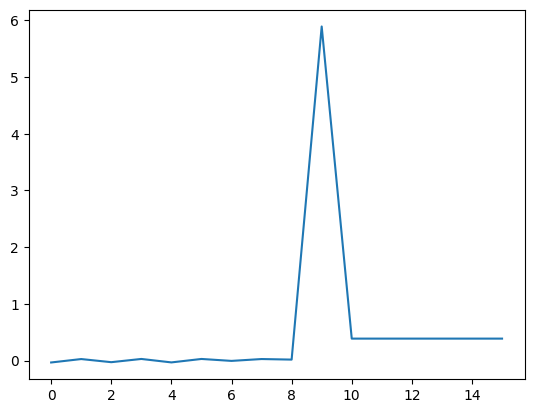

In [10]:
plt.plot(loss)

In [11]:
loss

[np.float64(-0.03305836272928516),
 np.float64(0.02729184138851176),
 np.float64(-0.027849212398867316),
 np.float64(0.029057729000714363),
 np.float64(-0.03178478854081828),
 np.float64(0.02898137112775441),
 np.float64(-0.005204287289281295),
 np.float64(0.027536372264180382),
 np.float64(0.017649421903761536),
 np.float64(5.890744702783709),
 np.float64(0.38767624725120686),
 np.float64(0.38767624725120686),
 np.float64(0.38767624725120686),
 np.float64(0.38767624725120686),
 np.float64(0.38767624725120686),
 np.float64(0.38767624725120686),
 np.float64(inf),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),